# **Simple Linear Regression – Marketing ROI Analysis**

**Project Overview**:

In this project, a marketing dataset will be analyzed using Python and statsmodels to build a Simple Linear Regression model. This will be done by preparing data, selecting predictive variables, implementing OLS regression, validating model assumptions, and interpreting statistical outputs to drive business decisions. This project aims to show how data science is used to translate raw data into actionable marketing insights.

Simple Linear Regression – Marketing ROI Analysis
Project Overview
In this project, you will analyze a marketing dataset using Python and statsmodels to build a Simple Linear Regression model. You will learn how to prepare data, select predictive variables, implement OLS regression, validate model assumptions, and interpret statistical outputs to drive business decisions. This project helps you understand how data science translates raw data into actionable marketing insights.

Step-by-Step Project Tasks
• Load and explore the dataset; handle missing values
• Perform exploratory data analysis (EDA) with visualizations
• Identify the independent variable (TV, Radio, or Social Media) most correlated with Sales
• Build an OLS regression model using statsmodels
• Create diagnostic plots to test Linearity, Normality, and Homoscedasticity
• Interpret R-squared, coefficients, and p-values in business context
• Formulate a clear ROI-based recommendation for marketing budget allocation

Project Goal
By the end of this project, your analysis should:
• Successfully load and clean the marketing dataset
• Visualize relationships and justify variable selection
• Fit a statistically valid Simple Linear Regression model
• Verify key regression assumptions through diagnostic plots
• Explain model results clearly to a non-technical stakeholder
• Recommend the marketing channel with the strongest ROI impact

Project Submission
GitHub repository link containing:
• Jupyter Notebook (e.g., regression_analysis.ipynb) with all cells executed
• README.md with project overview and environment setup instructions (e.g., pip install pandas seaborn statsmodels)
• Clean, well-commented code with Markdown explanations of your analytical reasoning

# 1.1 Importing and Cleaning Data

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm

In [2]:
# Importing data
df_sales = pd.read_csv("marketing_and_sales_data.csv")
df_sales.shape
df_sales.info()
df_sales.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [3]:
#Checking the data types of the data in the dataset
df_sales.select_dtypes(include="number")

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
...,...,...,...,...
4567,26.0,4.472360,0.717090,94.685866
4568,71.0,20.610685,6.545573,249.101915
4569,44.0,19.800072,5.096192,163.631457
4570,71.0,17.534640,1.940873,253.610411


In [4]:
df_sales.select_dtypes(exclude="number")

""
0
1
2
3
4
...
4567
4568
4569
4570


In [5]:
# Checking for null values
df_sales.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [6]:
#Drop null values
df_sales.dropna(axis=0, inplace=True)
df_sales.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [7]:
#Checking for duplicates
print(df_sales.duplicated().value_counts())
print(df_sales["TV"].duplicated().value_counts())
print(df_sales["Radio"].duplicated().value_counts())
print(df_sales["Social_Media"].duplicated().value_counts())
print(df_sales["Sales"].duplicated().value_counts())

False    4546
Name: count, dtype: int64
TV
True     4455
False      91
Name: count, dtype: int64
Radio
False    4546
Name: count, dtype: int64
Social_Media
False    4546
Name: count, dtype: int64
Sales
False    4546
Name: count, dtype: int64


In [8]:
#Counting values
df_sales["TV"].value_counts()

TV
43.0    70
40.0    67
47.0    65
21.0    64
34.0    64
        ..
76.0    36
81.0    35
91.0    34
71.0    32
57.0    31
Name: count, Length: 91, dtype: int64

In [9]:
df_sales.describe()

,TV,Radio,Social_Media,Sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54.062912,18.157533,3.323473,192.413332
std,26.104942,9.663260,2.211254,93.019873
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.555355,1.530822,112.434612
50%,53.000000,17.859513,3.055565,188.963678
75%,77.000000,25.640603,4.804919,272.324236
max,100.000000,48.871161,13.981662,364.079751


# 1.2. Exploratory Data Analysis (EDA)

Text(0, 0.5, 'Sales')

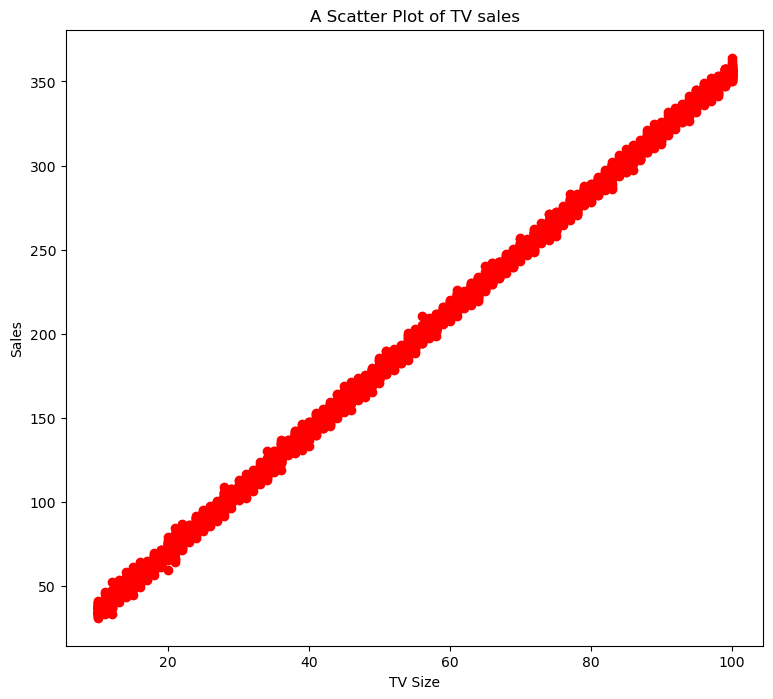

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(x=df_sales["TV"], y=df_sales["Sales"], color="red")
plt.title("A Scatter Plot of TV sales")
plt.xlabel("TV Size")
plt.ylabel("Sales")

Text(0, 0.5, 'Sales')

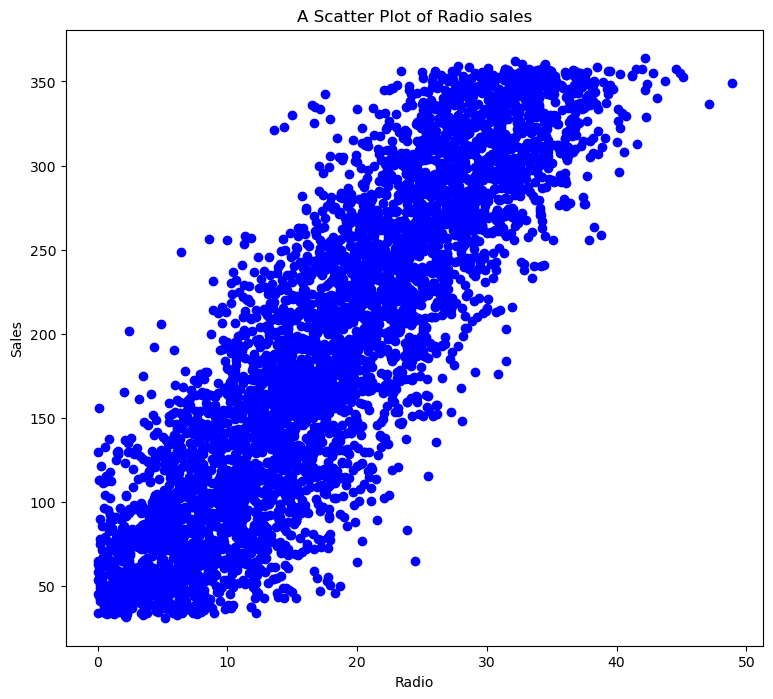

In [11]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(x=df_sales["Radio"], y=df_sales["Sales"], color="blue")
plt.title("A Scatter Plot of Radio sales")
plt.xlabel("Radio")
plt.ylabel("Sales")

Text(0, 0.5, 'Sales')

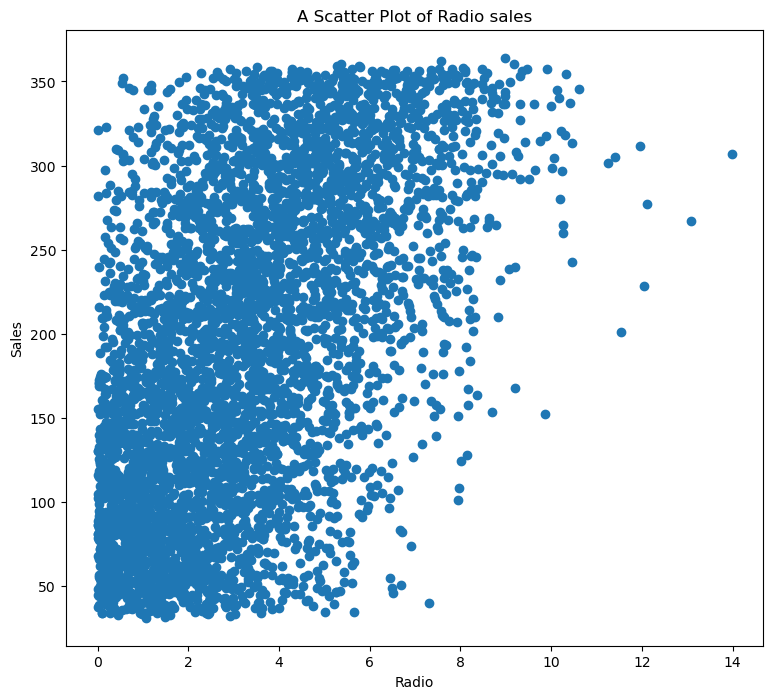

In [12]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(x=df_sales["Social_Media"], y=df_sales["Sales"])
plt.title("A Scatter Plot of Radio sales")
plt.xlabel("Radio")
plt.ylabel("Sales")

Text(0.5, 0, 'TV')

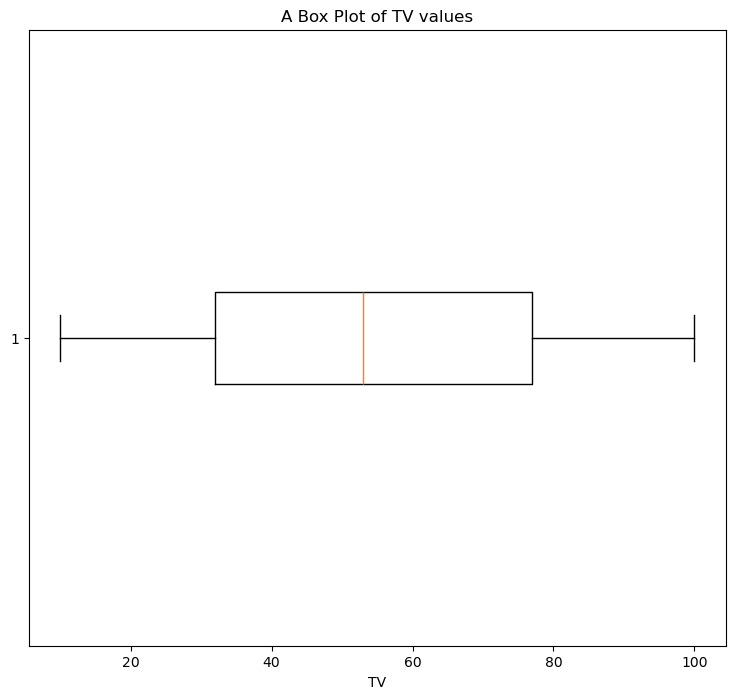

In [13]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.boxplot(df_sales["TV"], vert=False)
plt.title("A Box Plot of TV values")
plt.xlabel("TV")

Text(0.5, 0, 'Radio')

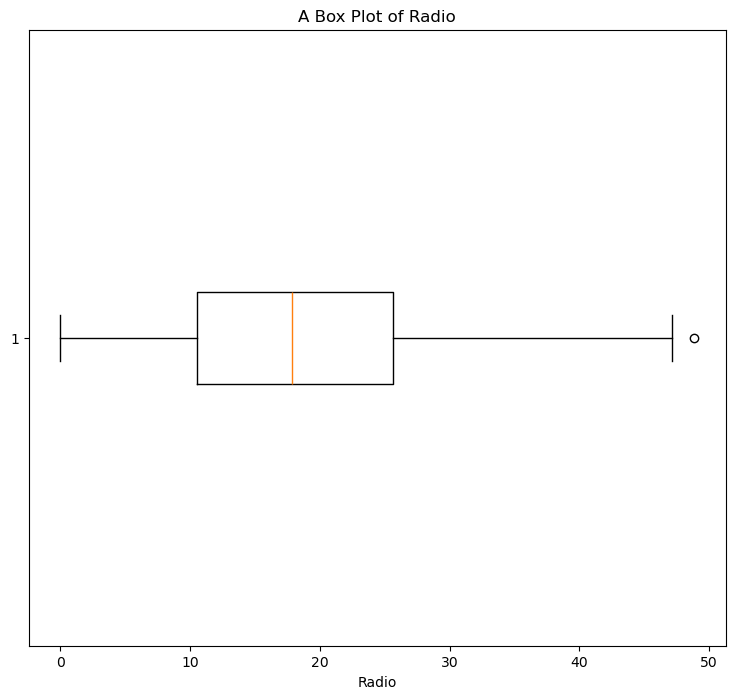

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.boxplot(df_sales["Radio"], vert=False)
plt.title("A Box Plot of Radio")
plt.xlabel("Radio")

Text(0.5, 0, 'Social Media')

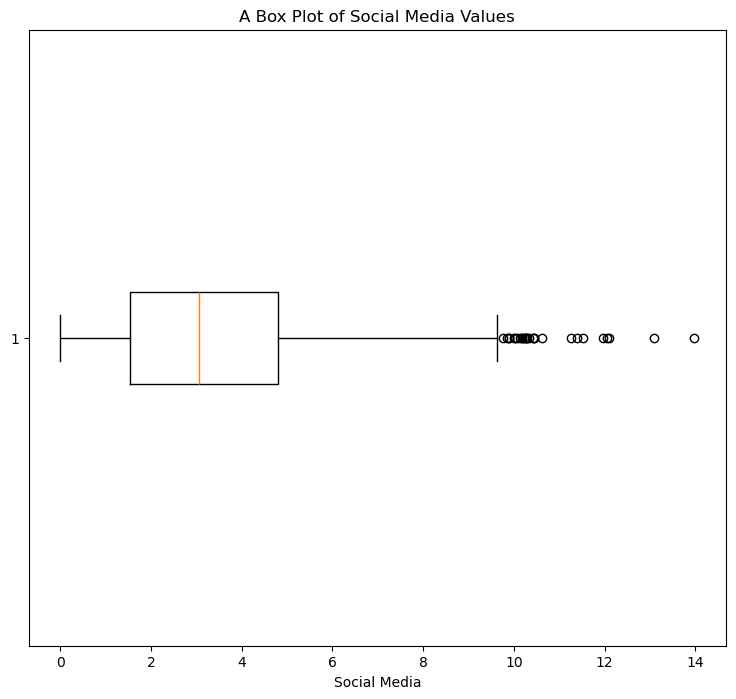

In [15]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.boxplot(df_sales["Social_Media"], vert=False)
plt.title("A Box Plot of Social Media Values")
plt.xlabel("Social Media")

Text(0.5, 0, 'Sales')

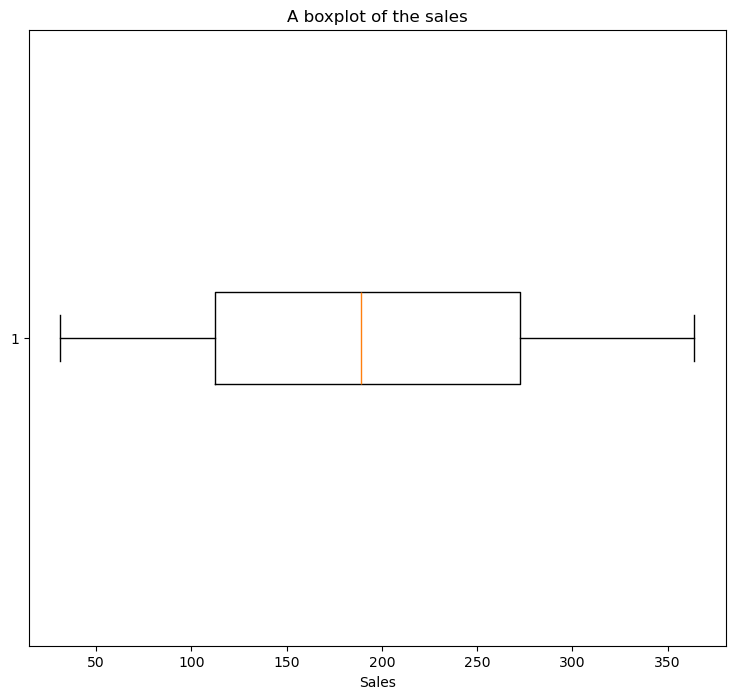

In [16]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.boxplot(df_sales["Sales"], vert=False)
plt.title("A boxplot of the sales")
plt.xlabel("Sales")

Text(0.5, 0, 'Social Media')

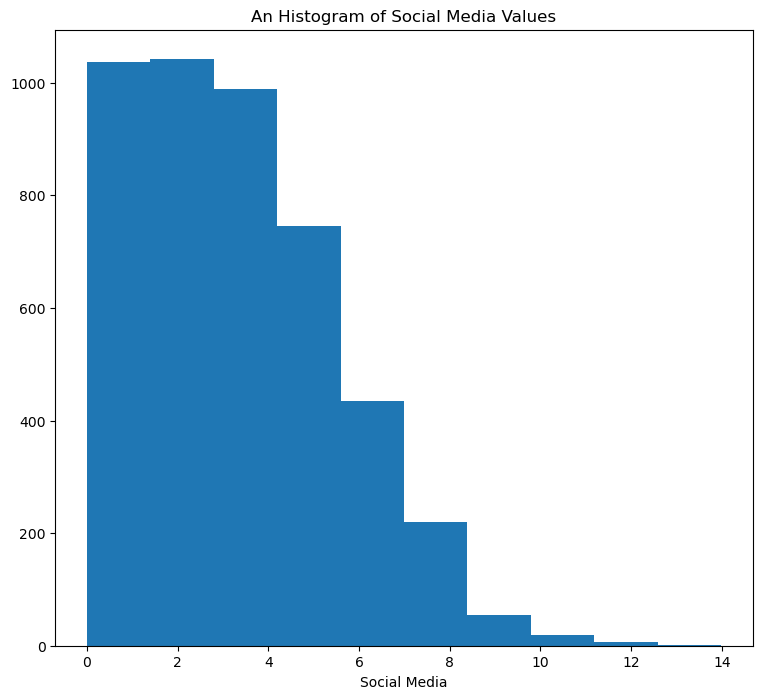

In [17]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.hist(df_sales["Social_Media"])
plt.title("An Histogram of Social Media Values")
plt.xlabel("Social Media")

The box plots and histogram indicate that there might be outliers in the Social media values. Further investigations will be carried out using Quantiles

In [18]:
# Calculating the Quantile
Q1 = df_sales.quantile(0.25)
Q3 = df_sales.quantile(0.75)
Qint = Q3 - Q1
#computing the range outside of which Outliers are defined
lower_bound = Q1 - 1.5*Qint
upper_bound = Q3 + 1.5*Qint

#converting the bound series to dictionaries
lower_bound_dict = lower_bound.to_dict()
upper_bound_dict = upper_bound.to_dict()


**Handling Outliers**

In [19]:

#Removing outliers lower than the lower bounds
for key in lower_bound_dict.keys():
    if (df_sales[key] < lower_bound_dict[key]).any():
        df_lower_outliers = df_sales[df_sales[key] < lower_bound_dict[key]]
        #printing outliers found
        print(df_lower_outliers)
        print(df_sales)
        #removing outliers with Pandas filtering
        df_sales = df_sales[df_sales[key] >= lower_bound_dict[key]]
    else:
        df_sales = df_sales

# Removing outliers greater than the upper bounds
for key in lower_bound_dict.keys():
    if (df_sales[key] > upper_bound_dict[key]).any():
        df_upper_outliers = df_sales[df_sales[key] > upper_bound_dict[key]]
        #printing outliers found
        print(df_upper_outliers)
        #removing outliers with masking/filtering
        df_sales = df_sales[df_sales[key] <= upper_bound_dict[key]]
    else:
        df_sales = df_sales

        TV      Radio  Social_Media       Sales
4331  99.0  48.871161      8.292208  349.156031
         TV      Radio  Social_Media       Sales
140    95.0  36.422306      9.997472  335.301431
212   100.0  32.920194      9.904286  357.124573
468    67.0  27.533561     10.453921  242.587371
504    85.0  36.077756     11.403625  304.970625
558    95.0  43.129332     10.174983  339.871732
603    73.0  31.327127     10.260554  259.859083
867    74.0  30.967507     13.083957  266.757198
1235   94.0  39.221198     10.420853  336.888405
1363   90.0  36.551512      9.883176  317.576616
1412   84.0  34.984570     11.260430  301.493120
1468   83.0  32.790106     10.243735  296.812238
1872   86.0  33.250050     10.063746  304.428485
1929   75.0  29.621449     10.260188  264.485251
2050  100.0  34.284714     10.337978  354.680451
2091   78.0  37.477608     12.108017  277.337551
2096   57.0  21.666267     11.534626  200.805601
2295   88.0  37.287223     11.964333  311.773774
2346   86.0  38.575779

In [20]:
df_sales

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
...,...,...,...,...
4567,26.0,4.472360,0.717090,94.685866
4568,71.0,20.610685,6.545573,249.101915
4569,44.0,19.800072,5.096192,163.631457
4570,71.0,17.534640,1.940873,253.610411


**Investigating Multicollinearity**

In [21]:
df_sales_corr = df_sales.corr(method="pearson", numeric_only=True)
df_sales_corr

,TV,Radio,Social_Media,Sales
TV,1.000000,0.868617,0.525867,0.999495
Radio,0.868617,1.000000,0.599865,0.868076
Social_Media,0.525867,0.599865,1.000000,0.525521
Sales,0.999495,0.868076,0.525521,1.000000


<Axes: >

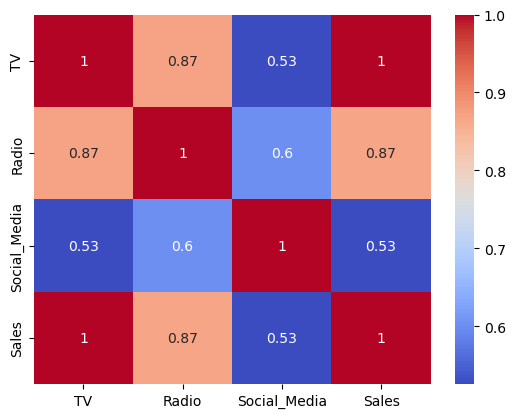

In [22]:
sns.heatmap(df_sales_corr, annot=True, cmap="coolwarm")

After the analysis, we can see that Radio and TV have strong correlations. In addition, TV has stronger correlations with Sales, hence we can drop TV

In [23]:
df_sales.drop(columns="Radio", inplace=True)

In [24]:
df_sales

,TV,Social_Media,Sales
0,16.0,2.907983,54.732757
1,13.0,2.409567,46.677897
2,41.0,2.913410,150.177829
3,83.0,6.922304,298.246340
4,15.0,1.405998,56.594181
...,...,...,...
4567,26.0,0.717090,94.685866
4568,71.0,6.545573,249.101915
4569,44.0,5.096192,163.631457
4570,71.0,1.940873,253.610411


# 1.3. ML Model Development

In [25]:
#feature matrix
X = df_sales.drop(columns="Sales")
#target vector
y = df_sales["Sales"]

In [26]:
X

,TV,Social_Media
0,16.0,2.907983
1,13.0,2.409567
2,41.0,2.913410
3,83.0,6.922304
4,15.0,1.405998
...,...,...
4567,26.0,0.717090
4568,71.0,6.545573
4569,44.0,5.096192
4570,71.0,1.940873


In [27]:
# Adding a constant term to the prediction
X = sm.add_constant(X)
#training model
model = sm.OLS(y, X)
result = model.fit()

# viewing the results
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.232e+06
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:02:35   Log-Likelihood:                -11297.
No. Observations:                4517   AIC:                         2.260e+04
Df Residuals:                    4514   BIC:                         2.262e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1297      0.103     -1.253   

# 1.4. Interpreting Key Metrics

1. An R-squared value of 0.999 means the independent variables of the model explains 99.9 percent of the observed variance in the dependent variable.
2. The p-value of Social media is 0.843. Because this is not less than 0.05, we say this is statistically insignificant. The TV advertisement channel feature is statistically significant.
3. The TV feature carries more weights (3.5617) in making predictions.
4. The social media feature has more standard error (0.024).
5. The p-value of the entire model, Prob (F-statistic), is 0.00, which indicates that the model is statistically significant.
6. The Prob (Omnibus) value is greater than 0.05 (0.984), which means the residuals are normally distributed.
7. The Cond. No (Condition number) is greater is 30, which means there might be redundant features. We can deduce that this redundant feature is Social Media.


# 1.5. Diagnostic Plots

In [28]:
fitted_values = result.fittedvalues
residuals = result.resid

Text(0, 0.5, 'Residual')

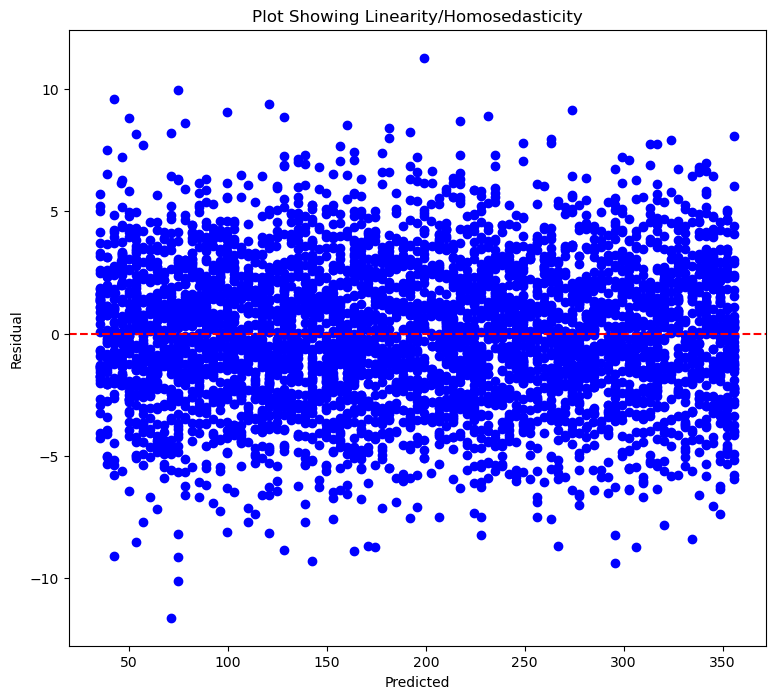

In [29]:
# Testing linearity and homosedasticity
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(fitted_values, residuals, color="blue")
ax.axhline(y=0, color="red", linestyle="--")
plt.title("Plot Showing Linearity/Homosedasticity")
plt.xlabel("Predicted")
plt.ylabel("Residual")

1. The scatter plot shows that there is a straight line relationship between the residuals and the fitted values. There is high linearity.
2. We also see that the points are approximately even distributed around the left and right side of the horizontal line. This indicates homosedasticity, i.e., there is equal spread/variance of errors/residuals.

Text(0.5, 0, 'Residuals')

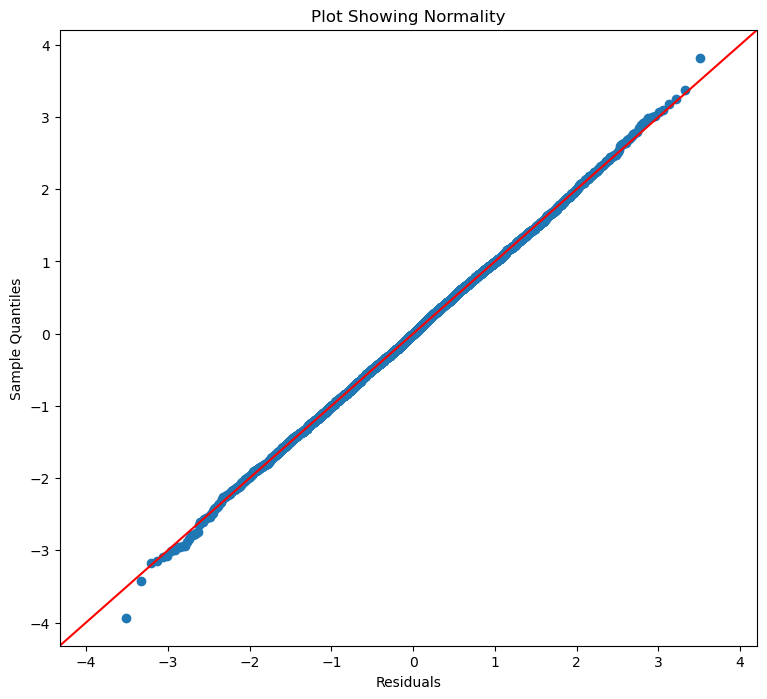

In [30]:
# Testing lNormality
fig, ax = plt.subplots(figsize=(9, 8))
sm.qqplot(residuals, line="45", fit=True, ax=ax)
plt.title("Plot Showing Normality")
plt.xlabel("Residuals")

Since the points closely follow the 45 degree line plot, we can say that the residuals are highly normally distributed

Text(0.5, 0, 'Residual')

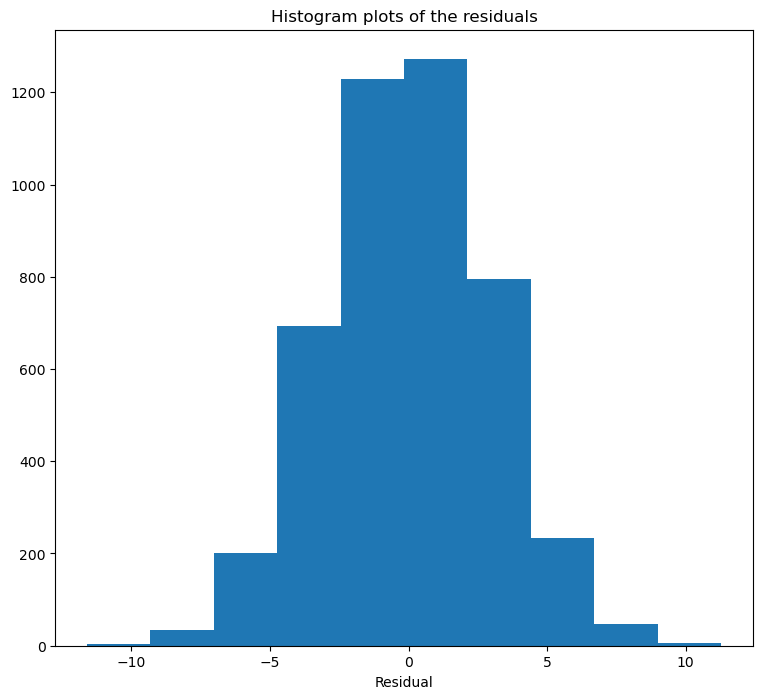

In [31]:
# Testing Normality
fig, ax = plt.subplots(figsize=(9, 8))
ax.hist(residuals)
plt.title("Histogram plots of the residuals")
plt.xlabel("Residual")

The histogram plot of the residuals show that the histogram is centred around 0, and shows a normal distribution curve. The histogram is symmetric

# 1.6. Recommendation

**Quick recommendation**

A clear ROI based recommendation is that more budgets should be allocated to marketing on TV. It has a high correlation with sales (pearson corr of 1). The OLS model also show that that it is the only statistically significant proper feature in predicting the dependent variable (sales). In essence, it has the highest return on investment.

**Strategic Marketing Recommendations**

Core Decision: Aggressively shift and allocate remaining marketing budgets directly to the TV advertising channel.

Business Context for Stakeholders:

Unmatched ROI: The OLS model proves that TV is the definitive driver of sales. For every unit of budget invested in TV, sales scale up reliably by a factor of $3.56$.

Eliminate Waste: Social Media performance is statistical noise within this dataset. Its high $p$-value ($0.843$) implies that changes in Social Media spend have no reliable, predictable impact on net Sales. Continuing to fund it represents inefficient capital allocation.High Predictability: Thanks to a $99.9\%$ $R$-squared metric and perfectly validated model diagnostics, marketing leadership can treat TV revenue forecasts with an exceptionally high degree of confidence.